In [1]:
#single cell sparse rda performance on simulated data.

import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import anndata as ad
import scipy.io
import os
from scipy.sparse import coo_matrix, csr_matrix
from pathlib import Path
import matplotlib.colors as mcolors

# --- Illustrator-editable figure settings ---
import matplotlib as mpl
sc.settings.vector_friendly = True
sc.set_figure_params(dpi=300)
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.size'] = 7
mpl.rcParams['axes.titlesize'] = 7
mpl.rcParams['axes.labelsize'] = 7
mpl.rcParams['xtick.labelsize'] = 6
mpl.rcParams['ytick.labelsize'] = 6
mpl.rcParams['legend.fontsize'] = 6

In [2]:
# Output directory for the realistic (touching-cluster) shift simulation.
output_dir = Path("/path/to/data/scrna_seq/simulation_shift_realistic")
output_dir.mkdir(parents=True, exist_ok=True)

simulation_type = "shift"  # de or shift

In [3]:
import random
import numpy as np
import scipy.sparse
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(0)
random.seed(0)

# ==========================================
# PART 1: SIMULATION GENERATOR (shift; touching clusters; variable #DE genes; no responders)
# ==========================================

def generate_nb_counts(n_cells, n_genes, mean_count, overdispersion=2.0):
    """Counts from a Negative Binomial distribution."""
    if overdispersion <= 1:
        raise ValueError("Overdispersion must be > 1.")
    variance = mean_count * overdispersion
    p = mean_count / variance
    n = (mean_count * p) / (1 - p)
    # float so downstream fractional identity/shift boosts can be added in place
    return np.random.negative_binomial(n=n, p=p, size=(n_cells, n_genes)).astype(np.float64)

print("--- Step 1: Generating Base Data ---")
nb_matrix = generate_nb_counts(n_cells=2400, n_genes=2000, mean_count=2.0, overdispersion=2.0)
counts = scipy.sparse.csr_matrix(nb_matrix)

control_adata = ad.AnnData(counts)
control_adata.var_names = [f"Gene{i}" for i in range(2000)]

indices = np.arange(control_adata.shape[0])
np.random.shuffle(indices)
control_adata = control_adata[indices].copy()
if scipy.sparse.issparse(control_adata.X):
    control_adata.X = control_adata.X.toarray()

n_cells = control_adata.shape[0]
group_size = 240
num_full_groups = n_cells // group_size
group_indices_list = [np.arange(i*group_size, (i+1)*group_size) for i in range(num_full_groups)]

genes = list(control_adata.var_names)
shuffled_genes = random.sample(genes, len(genes))
gene_cursor = 0

adatas_to_concat = []
cell_type_markers = {}          # variable-size disease (shift) marker sets, per cell type
cell_type_identity_genes = {}

control_batches = ['Ctrl_Batch_A', 'Ctrl_Batch_B', 'Ctrl_Batch_C', 'Ctrl_Batch_D']
disease_batches = ['Dis_Batch_X', 'Dis_Batch_Y', 'Dis_Batch_Z', 'Dis_Batch_W']

# --- Realistic (touching) cell-type identity programs ---------------------------------
# Shared identity-gene pool with an OVERLAPPING sliding window per cell type, plus a weak
# per-cell x per-gene boost, so cell-type clusters touch/blend like a real scRNA-seq
# dataset instead of forming isolated blobs. (Same approach as create_simulation_de.ipynb.)
IDENTITY_POOL_SIZE   = 300
IDENTITY_WIDTH       = 60
IDENTITY_STEP        = 25      # overlap between adjacent types = WIDTH - STEP = 35
IDENTITY_BOOST_SHAPE = 3.0     # per-cell gamma boost, mean ~= 1.5
IDENTITY_BOOST_SCALE = 0.5

identity_gene_pool = shuffled_genes[gene_cursor : gene_cursor + IDENTITY_POOL_SIZE]
gene_cursor += IDENTITY_POOL_SIZE

# Disease-shift magnitude. Kept MODERATE so DISEASE and CONTROL cells of a cell type stay
# together in the SAME cluster (condition is not its own cluster), while the NUMBER of
# shifted (DE) genes -- which VARIES per cell type (5, 10, ..., 50) -- drives a detectable
# per-cell divergence for scCST (see benchmark_shift.ipynb: divergence vs #DE genes).
# The shift is applied to ALL disease cells (no responder / non-responder split).
DISEASE_SHIFT = 5

print("--- Step 2: Injecting Signals (shift on ALL disease cells; variable #DE genes) ---")

for group_idx, g_idx in enumerate(group_indices_list):
    current_cell_type = f'CellType_{group_idx}'

    sub_control = control_adata[g_idx].copy()
    sub_control.obs['Cell_Type'] = current_cell_type
    sub_control.obs['condition'] = 'Control'

    sub_disease = sub_control.copy()
    sub_disease.obs_names = [f"{x}_disease" for x in sub_disease.obs_names]
    sub_disease.obs['condition'] = 'Disease'

    sub_control.obs['sim_batch'] = np.random.choice(control_batches, size=sub_control.shape[0])
    sub_disease.obs['sim_batch'] = np.random.choice(disease_batches, size=sub_disease.shape[0])

    # Shared low-level count noise
    common_noise = np.random.negative_binomial(n=1, p=0.5, size=sub_control.shape)
    sub_control.X += common_noise
    sub_disease.X += common_noise

    # --- A. Overlapping identity program (weaker, per-cell x per-gene noise -> touching clusters) ---
    start = group_idx * IDENTITY_STEP
    identity_genes = identity_gene_pool[start : start + IDENTITY_WIDTH]
    identity_indices = [sub_control.var_names.get_loc(g) for g in identity_genes]
    gene_weights = np.random.uniform(0.5, 1.5, size=len(identity_indices))
    boost_ctrl = np.random.gamma(IDENTITY_BOOST_SHAPE, IDENTITY_BOOST_SCALE, size=(sub_control.shape[0], 1))
    boost_dis  = np.random.gamma(IDENTITY_BOOST_SHAPE, IDENTITY_BOOST_SCALE, size=(sub_disease.shape[0], 1))
    sub_control.X[:, identity_indices] += boost_ctrl * gene_weights
    sub_disease.X[:, identity_indices] += boost_dis * gene_weights
    cell_type_identity_genes[current_cell_type] = list(identity_genes)

    # --- B. Disease shift on a VARIABLE number of DE genes (applied to ALL disease cells) ---
    num_marker_genes = 5 + (group_idx * 5)     # 5, 10, 15, ..., 50
    marker_genes = shuffled_genes[gene_cursor : gene_cursor + num_marker_genes]
    gene_cursor += num_marker_genes
    marker_indices = [sub_disease.var_names.get_loc(g) for g in marker_genes]
    sub_disease.X[:, marker_indices] += DISEASE_SHIFT     # control kept at baseline (no zeroing)
    cell_type_markers[current_cell_type] = list(marker_genes)
    print(f"Group {group_idx} ({current_cell_type}): {num_marker_genes} DE genes injected.")

    adatas_to_concat.append(sub_control)
    adatas_to_concat.append(sub_disease)

sim_adata = ad.concat(adatas_to_concat, axis=0, join='inner')
sim_adata.obs['sim_group_truth'] = sim_adata.obs['Cell_Type'].astype(str)
sim_adata.uns['cell_type_identity_genes'] = cell_type_identity_genes
sim_adata.uns['cell_type_markers'] = cell_type_markers

print(f"Simulation Complete: {sim_adata.n_obs} cells, {sim_adata.n_vars} genes.")

--- Step 1: Generating Base Data ---


--- Step 2: Injecting Signals (shift on ALL disease cells; variable #DE genes) ---
Group 0 (CellType_0): 5 DE genes injected.
Group 1 (CellType_1): 10 DE genes injected.
Group 2 (CellType_2): 15 DE genes injected.
Group 3 (CellType_3): 20 DE genes injected.
Group 4 (CellType_4): 25 DE genes injected.


Group 5 (CellType_5): 30 DE genes injected.
Group 6 (CellType_6): 35 DE genes injected.
Group 7 (CellType_7): 40 DE genes injected.
Group 8 (CellType_8): 45 DE genes injected.
Group 9 (CellType_9): 50 DE genes injected.


Simulation Complete: 4800 cells, 2000 genes.


2026-07-22 14:08:36,958 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


2026-07-22 14:08:37,554 - harmonypy - INFO - sklearn.KMeans initialization complete.


2026-07-22 14:08:37,575 - harmonypy - INFO - Iteration 1 of 50


2026-07-22 14:08:38,493 - harmonypy - INFO - Iteration 2 of 50


2026-07-22 14:08:39,419 - harmonypy - INFO - Iteration 3 of 50


...

2026-07-22 14:08:44,785 - harmonypy - INFO - Iteration 16 of 50


2026-07-22 14:08:45,096 - harmonypy - INFO - Iteration 17 of 50


2026-07-22 14:08:45,417 - harmonypy - INFO - Iteration 18 of 50


2026-07-22 14:08:45,730 - harmonypy - INFO - Converged after 18 iterations


2026-07-22 14:08:50.386759: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


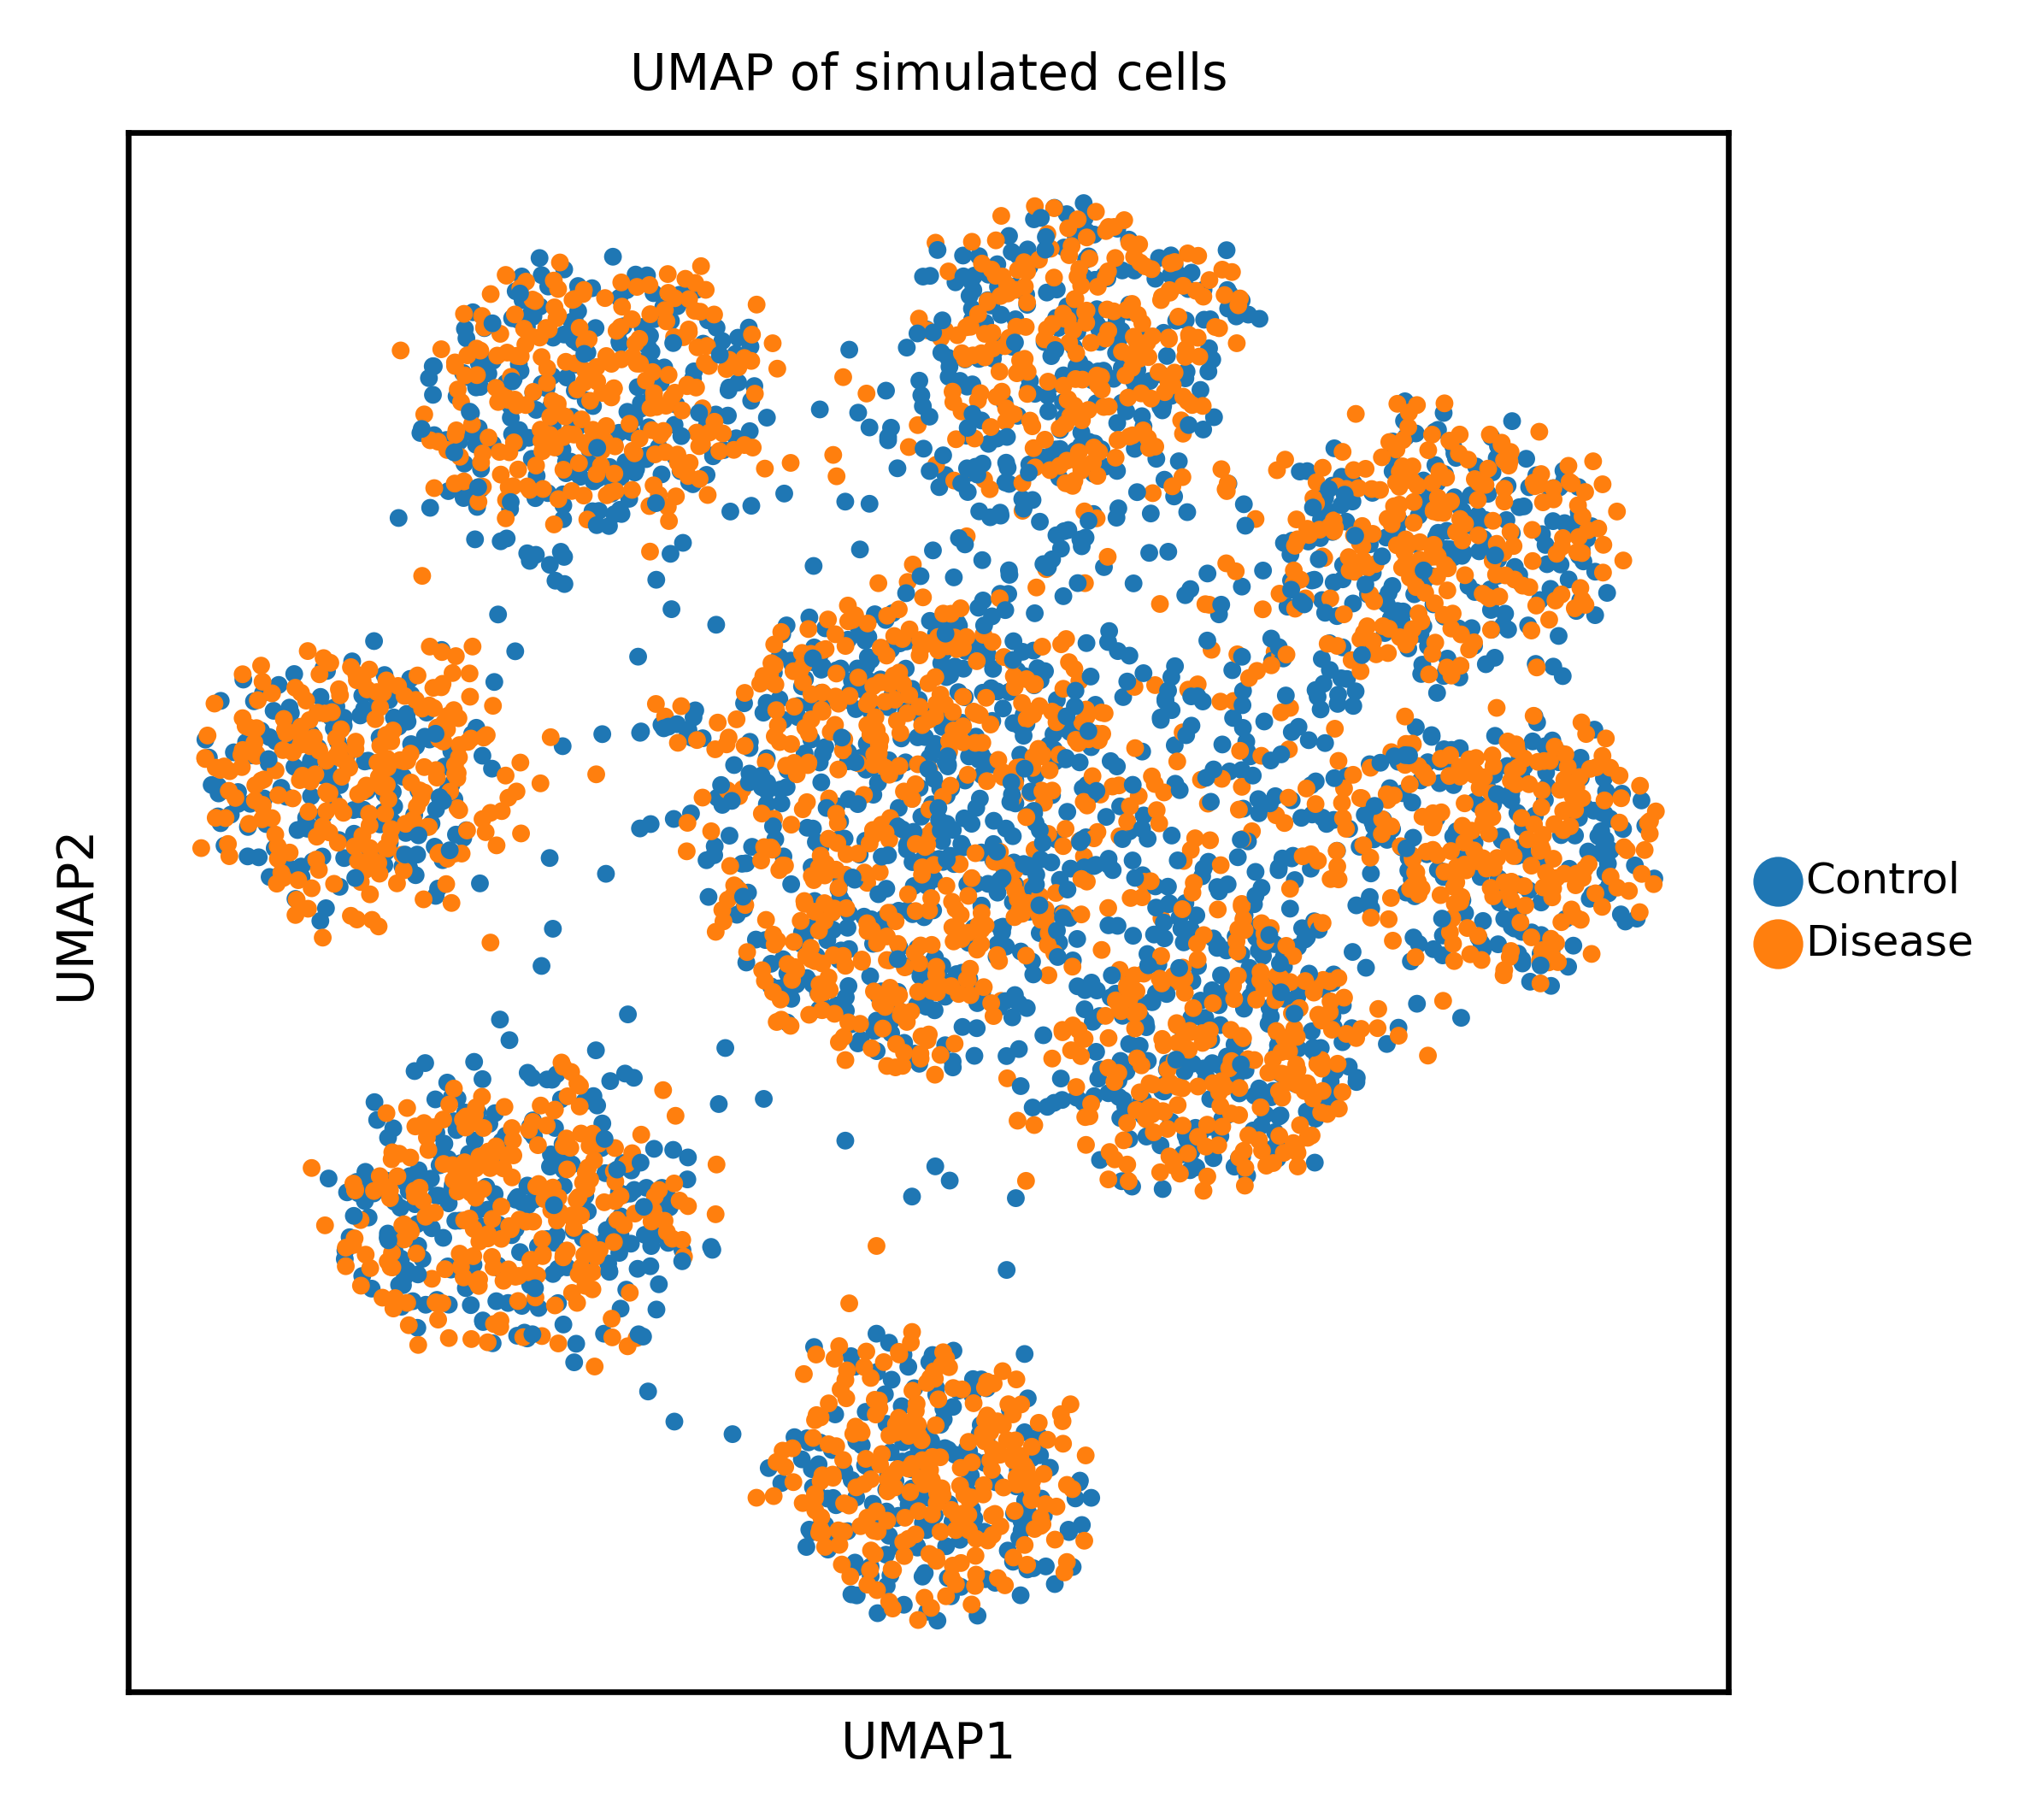

In [4]:
k_neighbors = 15
sc.pp.normalize_total(sim_adata)
sc.pp.log1p(sim_adata)

#Identify highly variable genes
sc.pp.highly_variable_genes(sim_adata, n_top_genes=2000)

#Perform PCA
sc.tl.pca(sim_adata, svd_solver='arpack')

# Run Harmony integration using the 'batch' column
sc.external.pp.harmony_integrate(sim_adata, key='sim_batch', max_iter_harmony=50)

#Compute neighbors and UMAP
sc.pp.neighbors(sim_adata, n_neighbors=k_neighbors, use_rep='X_pca_harmony')

sc.tl.umap(sim_adata)

sc.pl.umap(sim_adata, color='condition', title="UMAP of simulated cells")


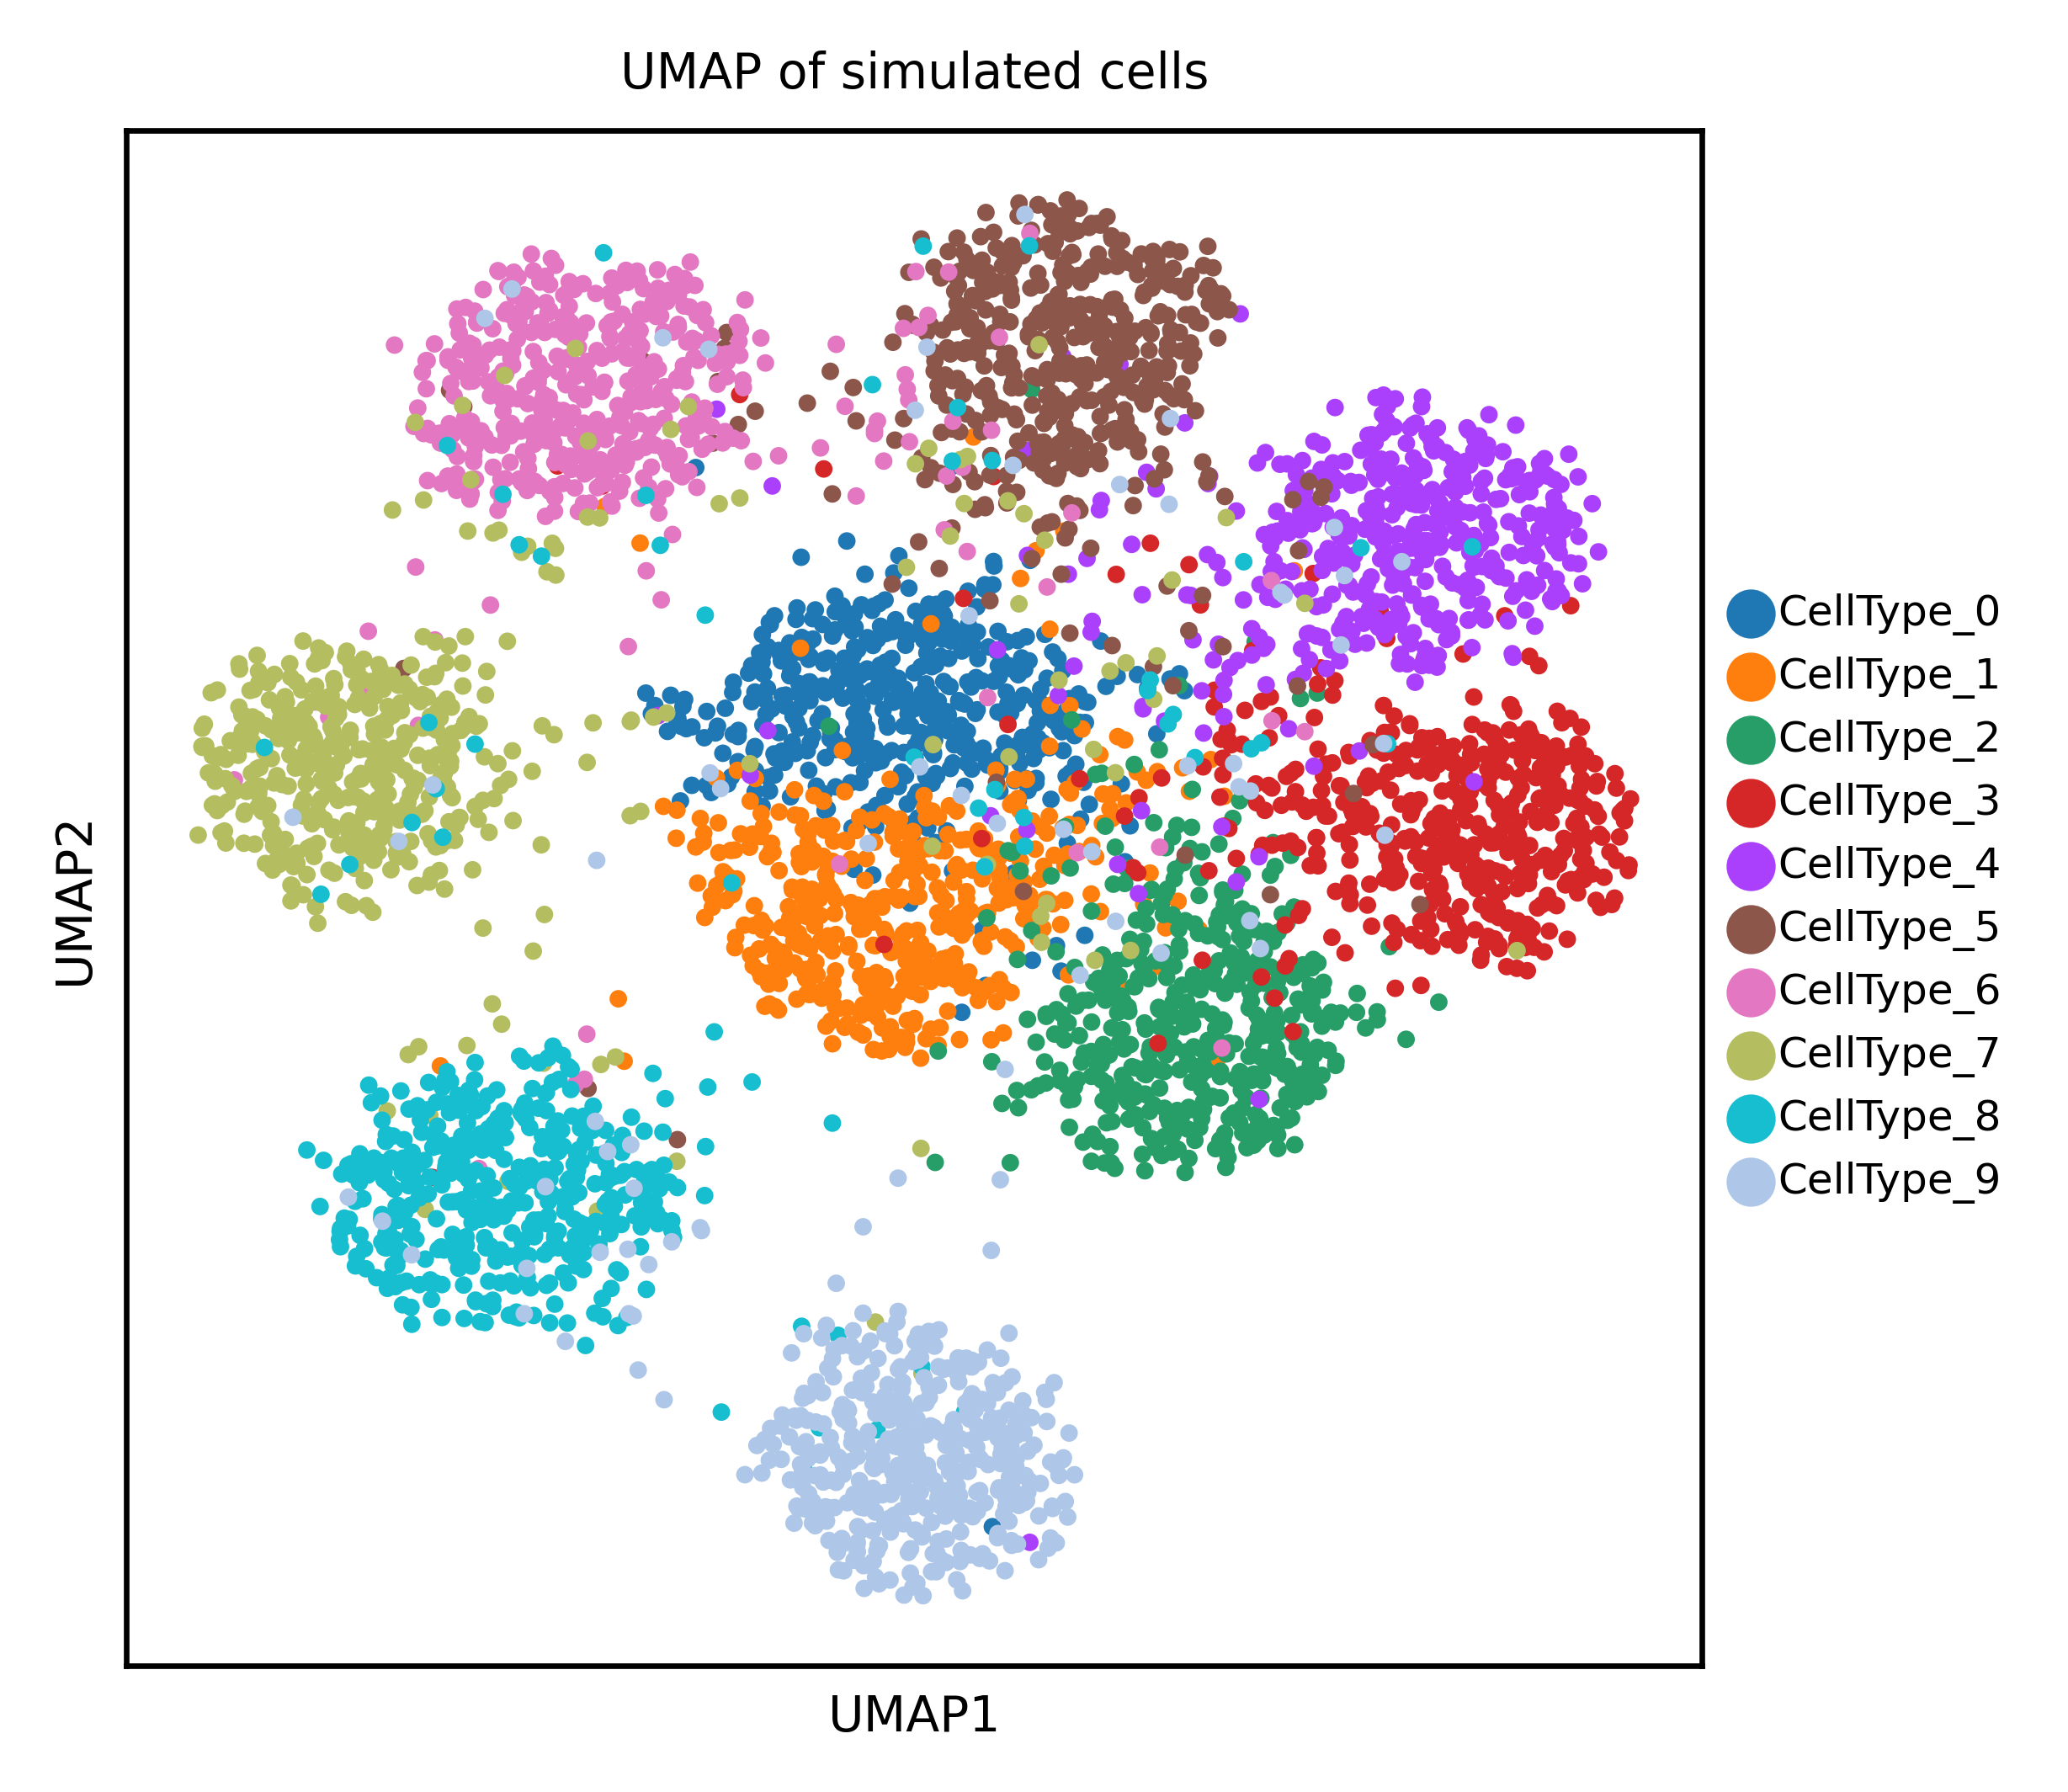

In [5]:
sc.pl.umap(sim_adata, color='Cell_Type', title="UMAP of simulated cells")

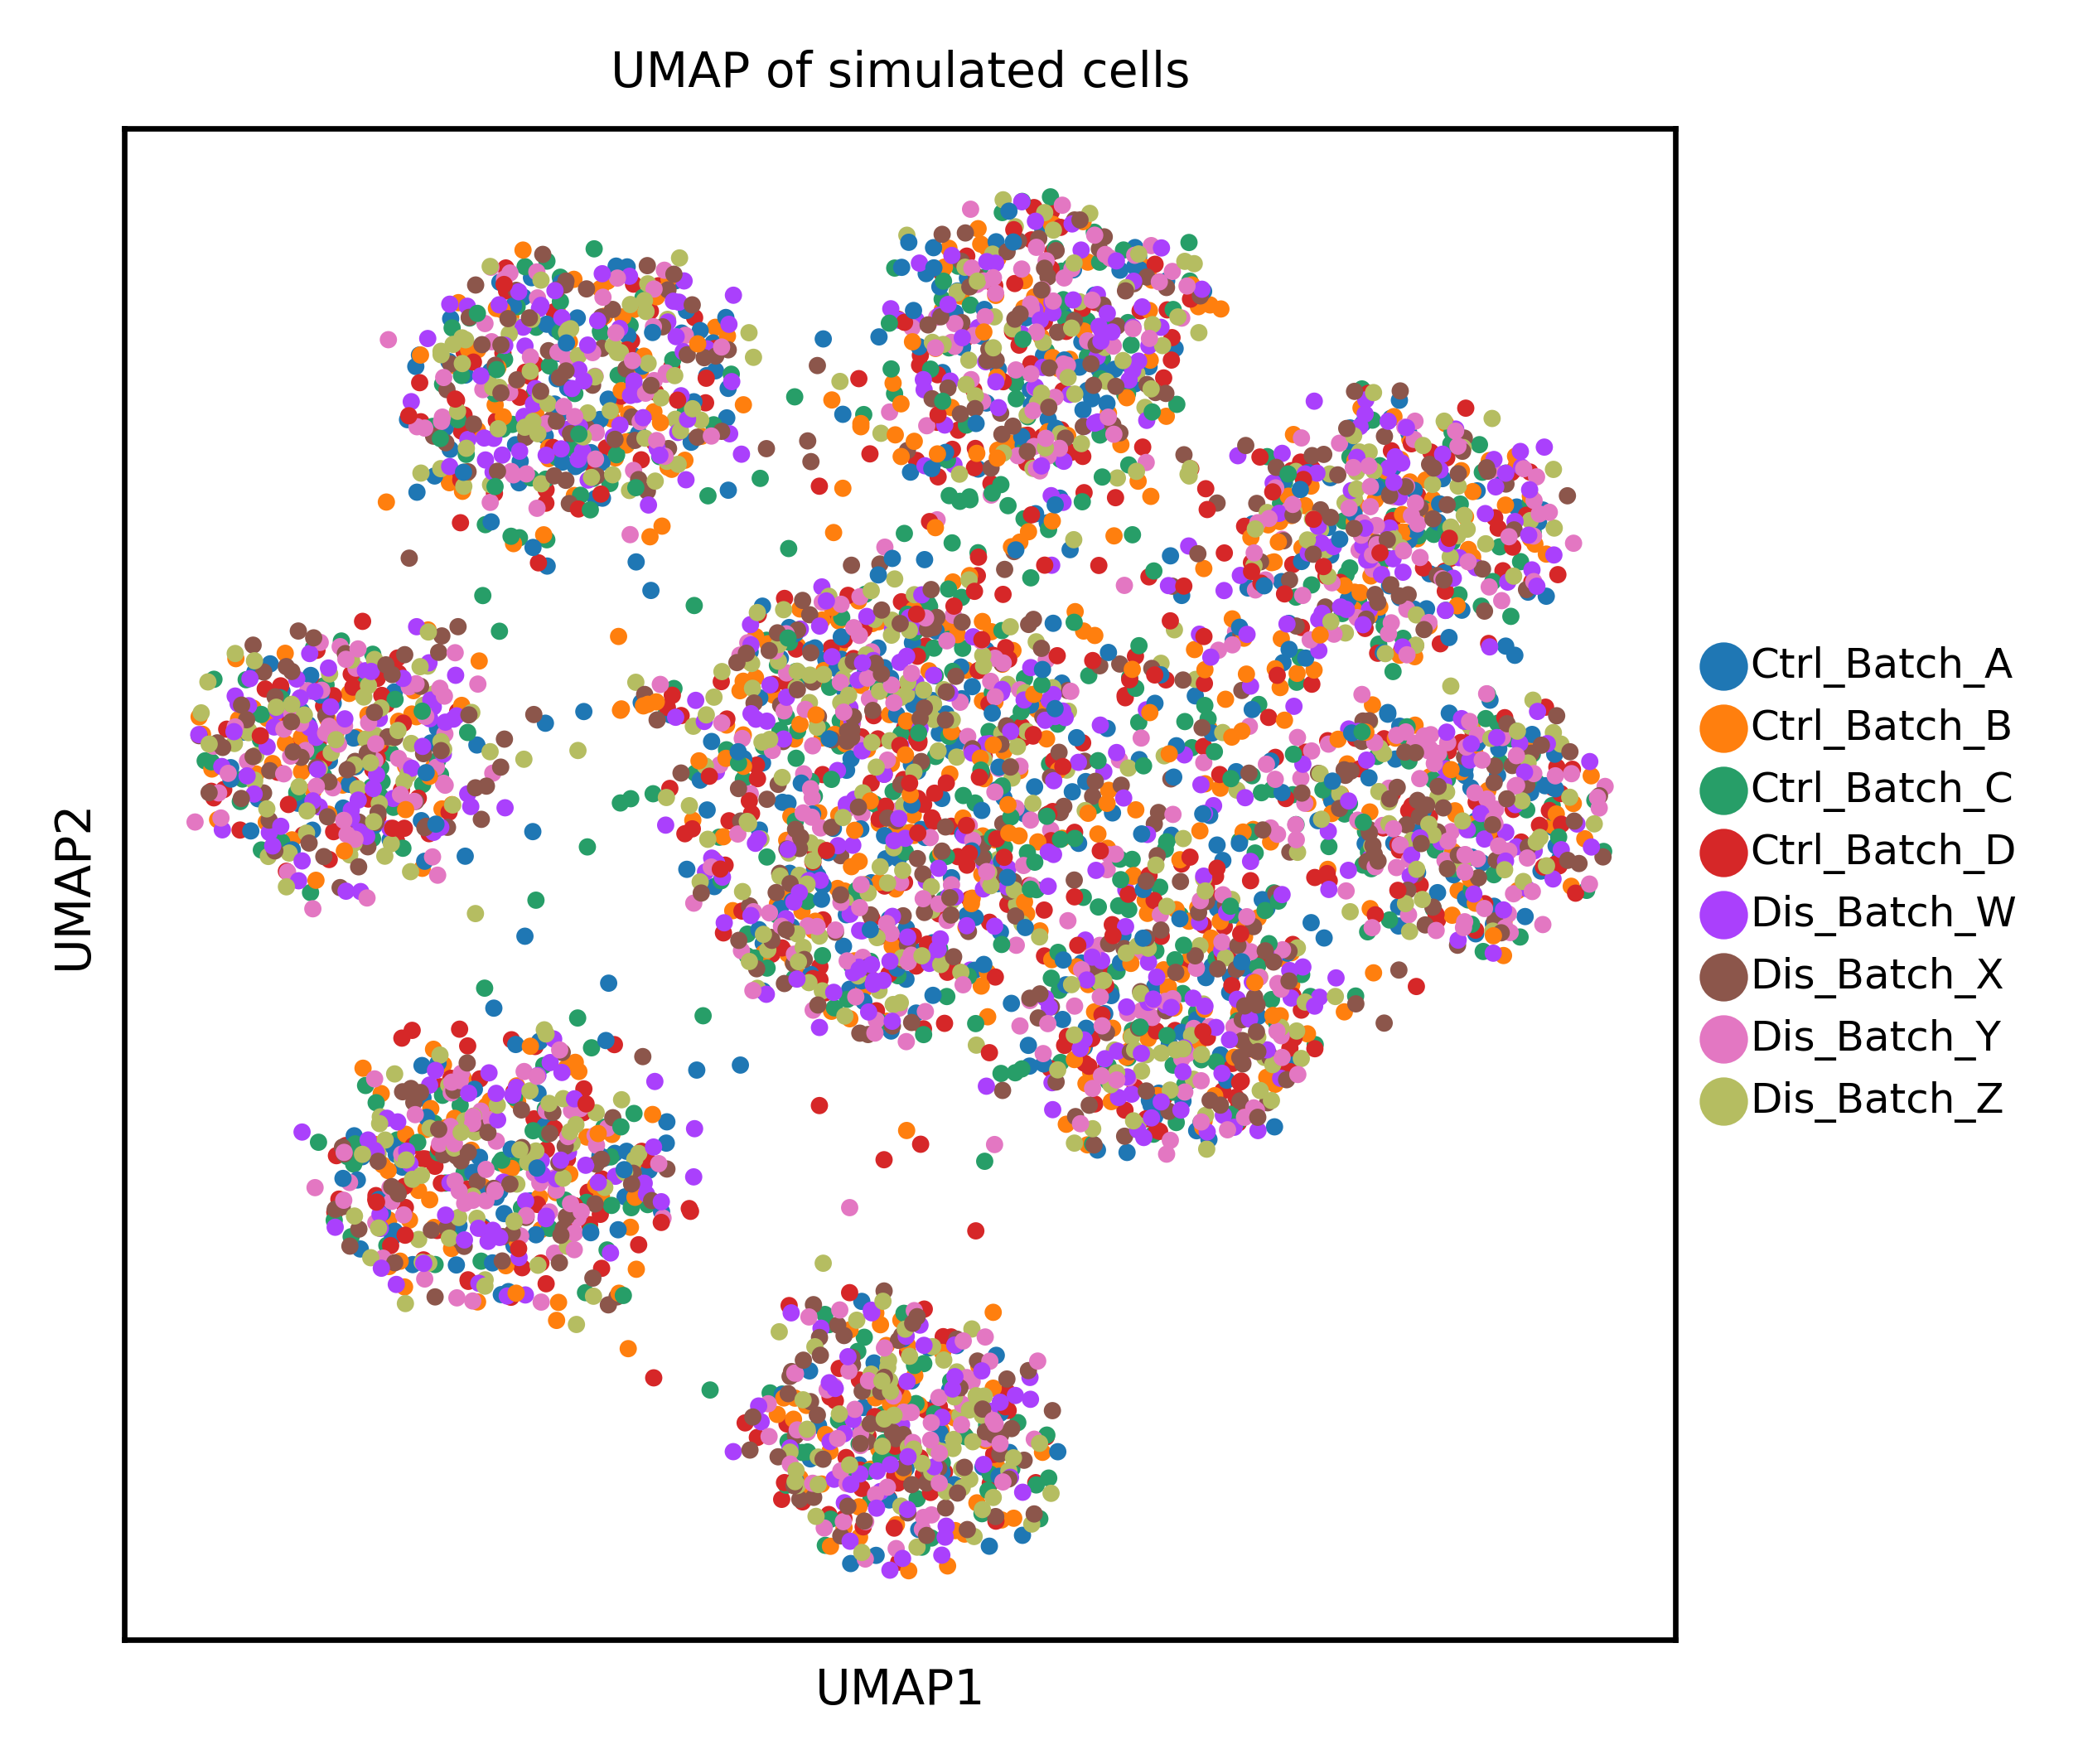

In [6]:
sc.pl.umap(sim_adata, color='sim_batch', title="UMAP of simulated cells")

In [7]:
sim_adata.obs

,Cell_Type,condition,sim_batch,sim_group_truth
1393,CellType_0,Control,Ctrl_Batch_C,CellType_0
2349,CellType_0,Control,Ctrl_Batch_A,CellType_0
299,CellType_0,Control,Ctrl_Batch_D,CellType_0
436,CellType_0,Control,Ctrl_Batch_D,CellType_0
128,CellType_0,Control,Ctrl_Batch_C,CellType_0
...,...,...,...,...
1388_disease,CellType_9,Disease,Dis_Batch_Z,CellType_9
967_disease,CellType_9,Disease,Dis_Batch_W,CellType_9
1455_disease,CellType_9,Disease,Dis_Batch_Z,CellType_9
1645_disease,CellType_9,Disease,Dis_Batch_Z,CellType_9


In [8]:
sim_adata.write(output_dir / f'simulation_adata_{simulation_type}.h5ad')